In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

resistance = 10000
# in Ω
capacitance = 10
# in uF
data = pd.read_csv("D:\Capacitance-Discharge Project\scope-data.csv", sep = ',')

Capacitor_A_Avg = (data["Capacitor A max"]+data["Capacitor A min"])/2
Capacitor_V_Avg = (data["Capacitor V max"]+data["Capacitor V min"])/2

data['Capacitor_A_Avg'] = Capacitor_A_Avg
data['Capacitor_V_Avg'] = Capacitor_V_Avg
clean_data_1 = data.drop(["Capacitor V min", "Capacitor V max", "Capacitor A min", "Capacitor A max"], axis = 1)
clean_data_2 = clean_data_1[clean_data_1["time"]>7.840]
clean_data_2

# Discharge filter
# Clean values between 0.25V to 4.75V
discharge = clean_data_2[(clean_data_2["Capacitor_V_Avg"]<4.5) & 
                         (clean_data_2["Capacitor_V_Avg"]>0.5)].copy()

# Why current is negative?
# During charging, current flows onto the capacitor, so it is +
# During discharging, current flows from capacitor to circuit, so it is -

# Reset time to initial t is 0: 
# No need to create another column and deleting the old one
discharge = discharge.assign(
    time = discharge["time"] - discharge["time"].min()
)

Text(0, 0.5, 'Vc')

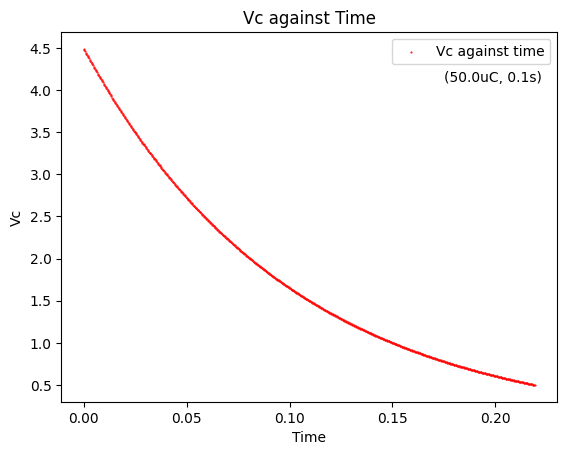

In [82]:
v_values = np.array(discharge['Capacitor_V_Avg'])
time = np.array(discharge['time'])

# Plotting
fig,ax = plt.subplots()
ax.scatter(time,v_values, s = 0.25, label = "Vc against time", color = 'red', linewidths = 1)
ax.legend()


# Values of Data:
voltage_peak = 5
charge = capacitance*voltage_peak
tau_theory = resistance*capacitance*10**-6
ax.annotate(
    text = f"({charge:.1f}uC, {tau_theory:.1f}s)",
    xy = (0.175,4.1),
)

# data:
ax.set_title("Vc against Time")
ax.set_xlabel("Time")
ax.set_ylabel("Vc")



In [ ]:
# Things to do:
# Model accuracy
# Fault detection
# Export

,time,Capacitor_A_Avg,Capacitor_V_Avg,ln(V_Avg/Vo)
615,0.00000,-0.000449,4.486870,-0.108283
616,0.00032,-0.000447,4.472535,-0.111483
617,0.00064,-0.000446,4.458246,-0.114683
618,0.00096,-0.000444,4.444002,-0.117883
619,0.00128,-0.000443,4.429804,-0.121083
...,...,...,...,...
1296,0.21792,-0.000051,0.507620,-2.287461
1297,0.21824,-0.000051,0.505998,-2.290661
1298,0.21856,-0.000050,0.504381,-2.293861
1299,0.21888,-0.000050,0.502770,-2.297061


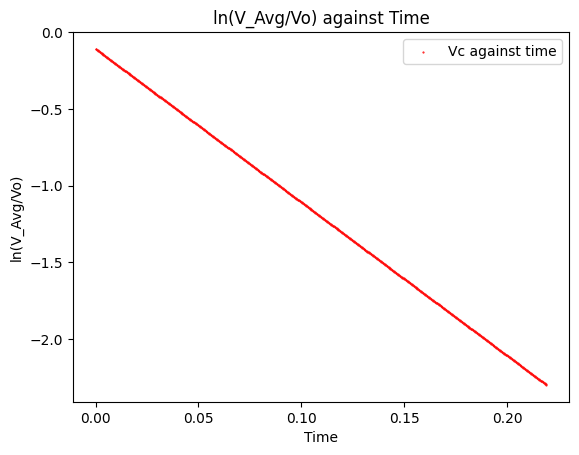

In [ ]:
# import math
# math expects only a single number, not a list, use np instead
# plot ln ... against t
discharge["ln(V_Avg/Vo)"] = np.log(discharge["Capacitor_V_Avg"]/voltage_peak)
v2_values = np.array(discharge['ln(V_Avg/Vo)'])

# Plotting
fig,ax = plt.subplots()
ax.scatter(time, v2_values, s = 0.25, label = "Vc against time", color = 'red', linewidths = 1)
ax.legend()


# Values of Data:
voltage_peak = 5
charge = capacitance*voltage_peak
time_constant = resistance*capacitance*10**-6

# data:
ax.set_title("ln(V_Avg/Vo) against Time")
ax.set_xlabel("Time")
ax.set_ylabel("ln(V_Avg/Vo)")

discharge.copy()


In [96]:
# Gradient:

from sklearn.linear_model import LinearRegression
model = LinearRegression()

x = np.array(time).reshape(-1, 1)
y = np.array(v2_values)

model.fit(x, y)
gradient = model.coef_[0]

tau_exp = -1/gradient

# Percentage error:
tau_calc = 100*(tau_exp-tau_theory)/tau_theory
print("Percentage Error of Tau:",tau_calc.round(6),"%")


Percentage Error of Tau: 0.001 %


In [ ]:
# Finding Half-Live (theory vs experimental), percentage error

# Method 1: 
# Use tau = t(1/2)/ln2
v_values = np.array(discharge['Capacitor_V_Avg'])
time = np.array(discharge['time'])

t_half_life = tau_exp*np.log(2)
discharge

# Method 2: Interpolation
# Since data no direct 4.5 to 2.25, can use regression, and move to find t (subject)

def time_voltage(v):
    return np.log(v/voltage_peak)/gradient

t1 = time_voltage(4.5)
t2 = time_voltage(2.25)

half_life = t2-t1

if t_half_life == half_life:
    print("Percentage Error is 0%")
else:
    pass

# same half life

Percentage Error is 0%


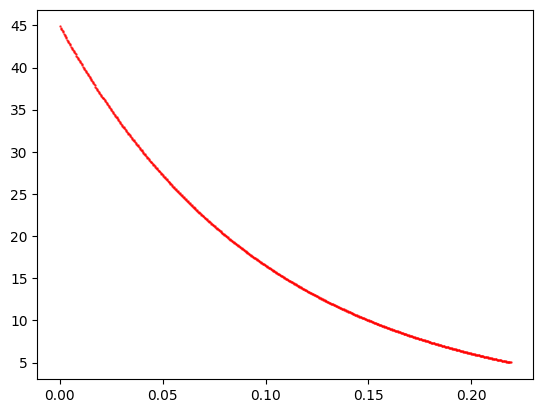

In [128]:
# Plot charge over time
# Q = CV
charge_with_time = v_values*capacitance

fig,ax = plt.subplots()
ax.scatter(time,charge_with_time, s = 0.5, alpha = 0.75, c = 'red')




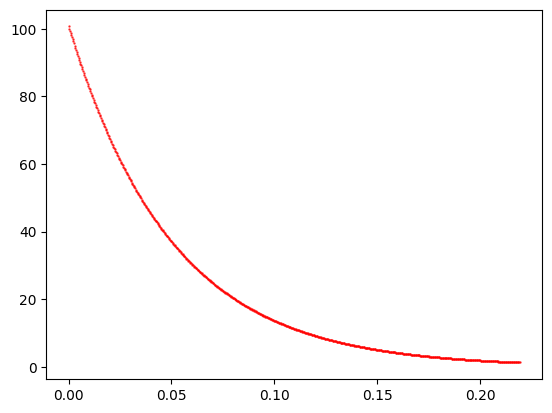

In [127]:
energy_with_time = 0.5*capacitance*v_values**2
fig,ax = plt.subplots()
ax.scatter(time,energy_with_time, s = 0.5, alpha = 0.75, c = 'red')

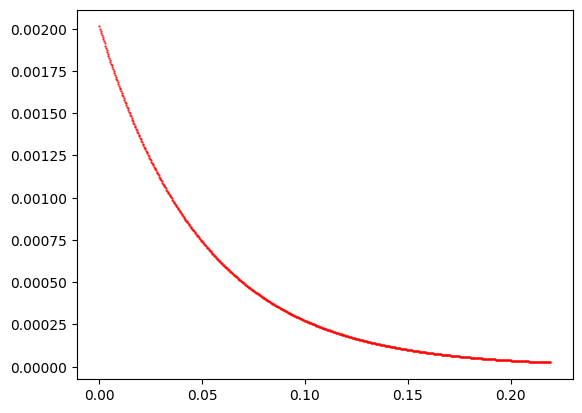

In [ ]:
# Plot I = Io * e^t/RC
discharge
# Finding Power
power = v_values**2/resistance
# Finding current
fig,ax = plt.subplots()
ax.scatter(time,power, s = 0.5, alpha = 0.75, c = 'red')




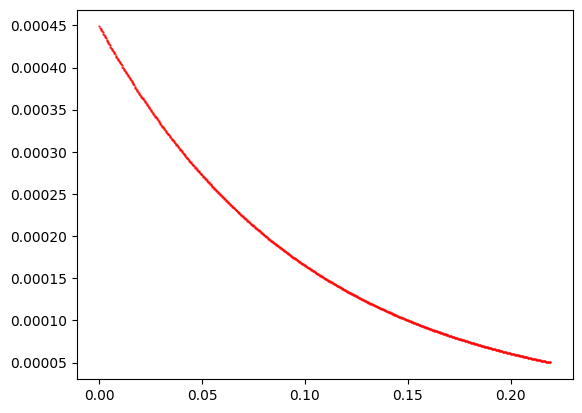

In [ ]:
# Finding Current
current_peak = voltage_peak/resistance
current_values = np.array(discharge["Capacitor_A_Avg"])


fig,ax = plt.subplots()
ax.scatter(time,-current_values, s = 0.5, alpha = 0.75, c = 'red')
